# Spurious Correlation: Chocolate Consumption vs. Nobel Prize Winners
Does eating more chocolate make a country smarter? A cross-country analysis inspired by the famous Messerli (2012) study published in the New England Journal of Medicine.

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import numpy as np

## Define the Dataset
Per capita chocolate consumption (kg/year) and Nobel Prize winners per 10 million inhabitants for 14 countries.

In [2]:
data = {
    "Country": ["Switzerland", "Sweden", "Denmark", "Austria", "Ireland", "Germany",
                "United Kingdom", "United States", "Netherlands", "France",
                "Belgium", "Italy", "Spain", "Brazil"],
    "Chocolate_Per_Capita_kg": [11.9, 8.8, 5.4, 8.6, 8.8, 8.4, 9.7, 5.3, 4.7, 6.3, 4.3, 2.8, 2.0, 1.0],
    "Nobel_Prizes_Per_10M": [32.0, 31.5, 25.0, 24.0, 21.0, 19.0, 18.5, 10.5, 10.0, 9.0, 8.5, 3.0, 1.5, 0.1],
}

df = pd.DataFrame(data)
df

,Country,Chocolate_Per_Capita_kg,Nobel_Prizes_Per_10M
0,Switzerland,11.9,32.0
1,Sweden,8.8,31.5
2,Denmark,5.4,25.0
3,Austria,8.6,24.0
4,Ireland,8.8,21.0
5,Germany,8.4,19.0
6,United Kingdom,9.7,18.5
7,United States,5.3,10.5
8,Netherlands,4.7,10.0
9,France,6.3,9.0


## Explore Data

In [3]:
print(df.describe())
print("\n")
df.info()

       Chocolate_Per_Capita_kg  Nobel_Prizes_Per_10M
count                14.000000             14.000000
mean                  6.285714             15.257143
std                   3.190336             10.660258
min                   1.000000              0.100000
25%                   4.400000              8.625000
50%                   5.850000             14.500000
75%                   8.750000             23.250000
max                  11.900000             32.000000


<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  14 non-null     str    
 1   Chocolate_Per_Capita_kg  14 non-null     float64
 2   Nobel_Prizes_Per_10M     14 non-null     float64
dtypes: float64(2), str(1)
memory usage: 468.0 bytes


## Calculate Correlation Coefficient

In [4]:
correlation = df["Chocolate_Per_Capita_kg"].corr(df["Nobel_Prizes_Per_10M"])
print(f"The correlation coefficient is: {correlation:.4f}")

The correlation coefficient is: 0.8776


## Scatter Plot with Country Labels
The classic chocolate vs. Nobel prizes scatter plot — does eating chocolate make you smarter?

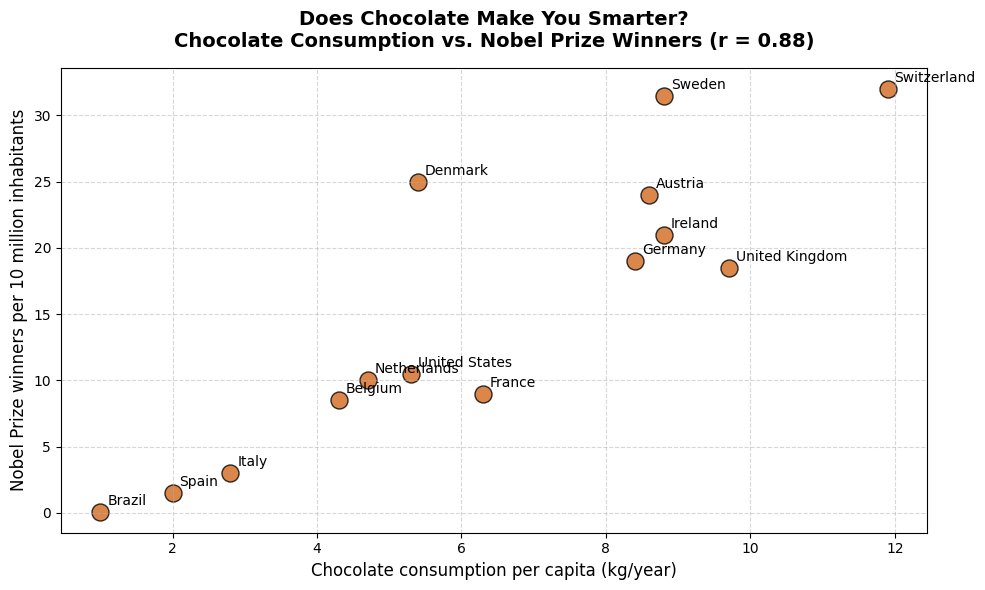

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Chocolate_Per_Capita_kg"],
    df["Nobel_Prizes_Per_10M"],
    color="chocolate",
    s=150,
    alpha=0.8,
    edgecolors="black",
)

# Add country labels
for i, txt in enumerate(df["Country"]):
    plt.annotate(
        txt,
        (df["Chocolate_Per_Capita_kg"][i], df["Nobel_Prizes_Per_10M"][i]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
    )

plt.title(
    f"Does Chocolate Make You Smarter?\nChocolate Consumption vs. Nobel Prize Winners (r = {correlation:.2f})",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Chocolate consumption per capita (kg/year)", fontsize=12)
plt.ylabel("Nobel Prize winners per 10 million inhabitants", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Statistical Significance Test

In [6]:
r, p_value = stats.pearsonr(df["Chocolate_Per_Capita_kg"], df["Nobel_Prizes_Per_10M"])
print(f"Pearson correlation: r = {r:.4f}")
print(f"P-value: p = {p_value:.6f}")
print(f"\nStatistically significant (p < 0.05)? {'Yes' if p_value < 0.05 else 'No'}")
print(f"\nR² = {r**2:.4f} — chocolate 'explains' {r**2*100:.1f}% of the variation in Nobel prizes")
print(f"\nBut of course, eating chocolate does NOT make you win a Nobel Prize!")

Pearson correlation: r = 0.8776
P-value: p = 0.000037

Statistically significant (p < 0.05)? Yes

R² = 0.7702 — chocolate 'explains' 77.0% of the variation in Nobel prizes

But of course, eating chocolate does NOT make you win a Nobel Prize!


## Scatter Plot with Regression Line

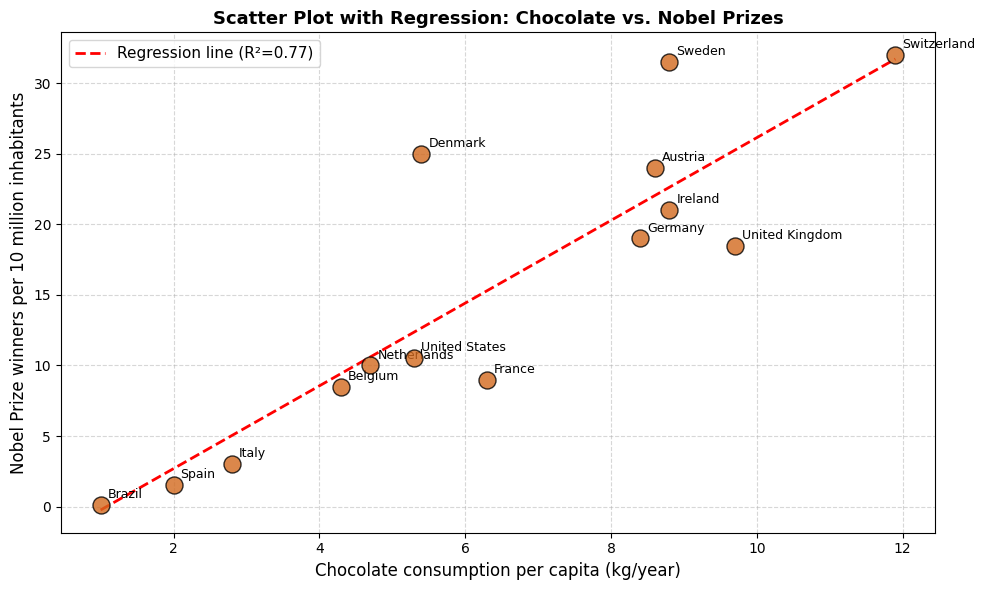


WHY THIS CORRELATION IS MISLEADING

This correlation was published in the New England Journal of 
Medicine (Messerli, 2012) — partly as a tongue-in-cheek example.

The real confounders are likely:
1. GDP/Wealth - rich countries can afford both chocolate AND 
   research universities
2. Education spending - correlated with both variables
3. Climate/Culture - Northern European countries happen to eat 
   more chocolate AND have strong academic traditions

The lesson: when a CONFOUNDER (wealth) drives both variables,
you get a strong correlation without any direct causation.

Source: Messerli FH. "Chocolate Consumption, Cognitive Function, 
and Nobel Laureates." N Engl J Med 2012; 367:1562-1564



In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df["Chocolate_Per_Capita_kg"], df["Nobel_Prizes_Per_10M"],
           color="chocolate", s=150, alpha=0.8, edgecolors="black", zorder=5)

# Regression line
slope, intercept, r_value, p_val, std_err = stats.linregress(
    df["Chocolate_Per_Capita_kg"], df["Nobel_Prizes_Per_10M"]
)
x_line = np.linspace(df["Chocolate_Per_Capita_kg"].min(), df["Chocolate_Per_Capita_kg"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="red", linewidth=2, linestyle="--",
        label=f"Regression line (R²={r_value**2:.2f})")

# Country labels
for i, txt in enumerate(df["Country"]):
    ax.annotate(txt, (df["Chocolate_Per_Capita_kg"][i], df["Nobel_Prizes_Per_10M"][i]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)

ax.set_xlabel("Chocolate consumption per capita (kg/year)", fontsize=12)
ax.set_ylabel("Nobel Prize winners per 10 million inhabitants", fontsize=12)
ax.set_title("Scatter Plot with Regression: Chocolate vs. Nobel Prizes", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("WHY THIS CORRELATION IS MISLEADING")
print("="*60)
print("""
This correlation was published in the New England Journal of 
Medicine (Messerli, 2012) — partly as a tongue-in-cheek example.

The real confounders are likely:
1. GDP/Wealth - rich countries can afford both chocolate AND 
   research universities
2. Education spending - correlated with both variables
3. Climate/Culture - Northern European countries happen to eat 
   more chocolate AND have strong academic traditions

The lesson: when a CONFOUNDER (wealth) drives both variables,
you get a strong correlation without any direct causation.

Source: Messerli FH. "Chocolate Consumption, Cognitive Function, 
and Nobel Laureates." N Engl J Med 2012; 367:1562-1564
""")